<a href="https://colab.research.google.com/github/babi00/ai4biological-pattern/blob/guido-clean/invasive_plants_analysis/embeddings_UMAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import umap
import hdbscan
import numpy as np
from google.colab import drive
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import collections as Counter
import plotly.express as px


%matplotlib inline

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
def cluster_embeddings_with_umap_hdbscan(embeddings, min_cluster_size=15, n_neighbors=15, min_dist=0.1, metric="euclidean"):
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, metric=metric, random_state=42)
    reduced = reducer.fit_transform(embeddings)

    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, metric=metric)
    cluster_labels = clusterer.fit_predict(reduced)

    return reduced, cluster_labels

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

embeddings = torch.load('/content/drive/MyDrive/Thesis/bioclip2_groups_embeddings_v0.pt')

embeddings_np = embeddings['embeddings'].cpu().numpy()

print(embeddings_np.shape) #(45361, 768) 43913 immagini da 768 dimensioni

print(embeddings)

Using device: cuda
(45361, 768)
{'embeddings': tensor([[ 0.0829,  0.0770,  0.0006,  ...,  0.0208, -0.0065, -0.0556],
        [ 0.0748,  0.0709,  0.0236,  ...,  0.0313, -0.0026, -0.0596],
        [ 0.0440,  0.0682,  0.0544,  ..., -0.0042, -0.0067, -0.0381],
        ...,
        [ 0.0498,  0.0791,  0.0285,  ..., -0.0101,  0.0063,  0.0182],
        [ 0.0506,  0.0534,  0.0445,  ..., -0.0081, -0.0277,  0.0134],
        [ 0.0892,  0.0909,  0.0002,  ..., -0.0075, -0.0539, -0.0163]],
       device='cuda:0'), 'labels': tensor([1, 1, 1,  ..., 1, 1, 1], device='cuda:0'), 'ids': tensor([    0,     1,     2,  ..., 45358, 45359, 45360], device='cuda:0'), 'groups': ['lythrum_curtissii', 'lythrum_curtissii', 'lythrum_curtissii', 'lythrum_curtissii', 'lythrum_curtissii', 'lythrum_curtissii', 'lythrum_curtissii', 'lythrum_curtissii', 'lythrum_curtissii', 'lythrum_curtissii', 'lythrum_curtissii', 'lythrum_curtissii', 'lythrum_curtissii', 'lythrum_curtissii', 'lythrum_curtissii', 'lythrum_borysthenicum', 

In [5]:
from collections import Counter

print(Counter(embeddings['labels'].cpu().numpy()))

Counter({np.int64(0): 24833, np.int64(1): 20528})


In [6]:
reduced_embeddings, cluster_labels = cluster_embeddings_with_umap_hdbscan(embeddings_np)

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [7]:
print(max(cluster_labels))

39


Text(0.5, 1.0, 'HDBSCAN projection of the embeddings')

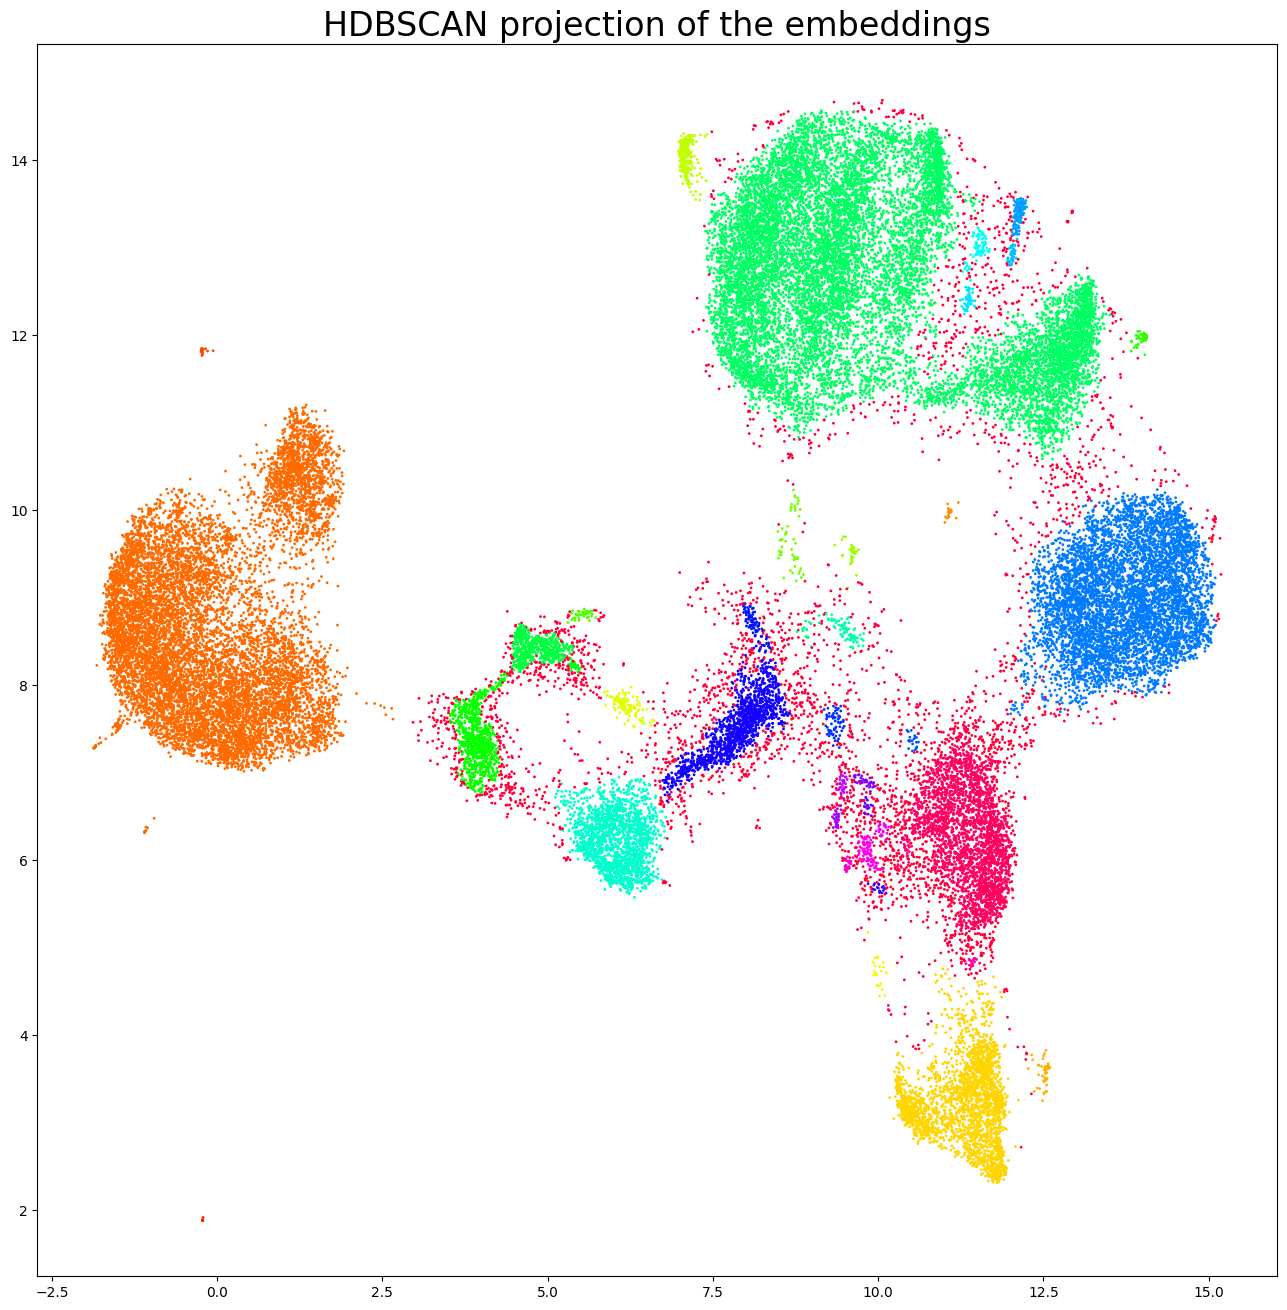

In [8]:
x = [red[0] for red in reduced_embeddings]
y = [red[1] for red in reduced_embeddings]


unique_labels = set(cluster_labels)
palette = sns.color_palette("hsv", len(unique_labels))
label_color_map = {label: palette[i] for i, label in enumerate(unique_labels)}
colors = [label_color_map[label] for label in cluster_labels]

plt.figure(figsize=(16, 16))
plt.scatter(x, y, c=colors, s=1)
plt.title("HDBSCAN projection of the embeddings", fontsize=24)

In [9]:

# Prepare data
df = pd.DataFrame({
    'UMAP1': [point[0] for point in reduced_embeddings],
    'UMAP2': [point[1] for point in reduced_embeddings],
    'Cluster': cluster_labels,
    'Species': embeddings['groups']
})

# Convert species to list if it's a tensor
if hasattr(df['Species'].iloc[0], 'item'):
    df['Species'] = df['Species'].apply(lambda x: x.item())

# Create interactive plot
fig = px.scatter(
    df,
    x='UMAP1',
    y='UMAP2',
    color='Cluster',
    hover_data=['Species', 'Cluster'],
    title='Interactive UMAP Projection with Cluster and Species Hover Info',
    width=1400,
    height=1000
)

fig.update_traces(marker=dict(size=3))  # 👈 reduce dot size here
fig.write_html('/content/drive/MyDrive/Thesis/interactive_plot_v0.html')
fig.show()